In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 


In [2]:
df=pd.read_csv("diabetes.csv")

## Basic Data Analysis

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df['Pregnancies'].mean()

3.8450520833333335

## Exploratory Data Analysis

Analysis of the 'Pregnancies' Feature

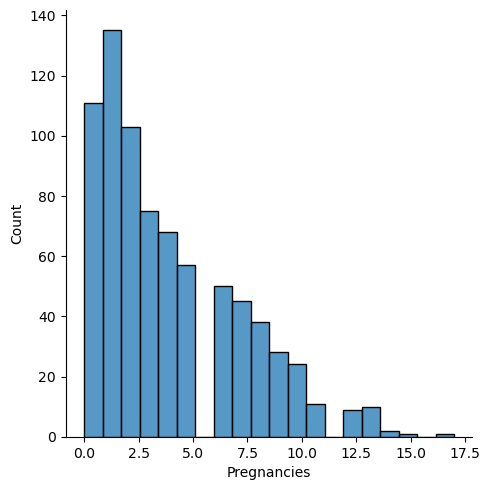

In [11]:
sns.displot(x=df['Pregnancies'],bins=20)

<Axes: ylabel='Density'>

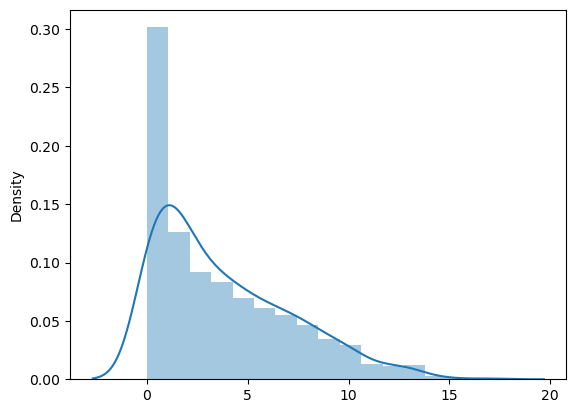

In [12]:
import warnings
warnings.filterwarnings('ignore')
sns.distplot(x=df['Pregnancies'])

<Axes: xlabel='Pregnancies'>

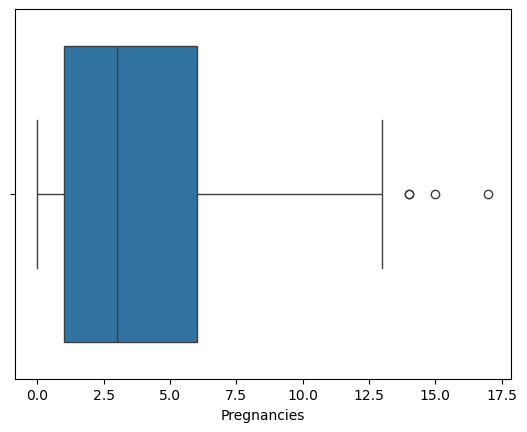

In [13]:
sns.boxplot(x=df['Pregnancies'])

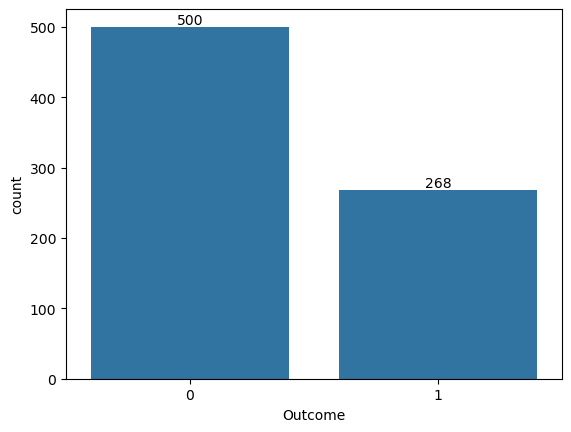

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(x=df['Outcome'])

for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

Pregnancies vs. Diabetes Outcome

In [15]:
preg_stats = df.groupby('Outcome')['Pregnancies'].describe()
print(preg_stats)

         count      mean       std  min   25%  50%  75%   max
Outcome                                                      
0        500.0  3.298000  3.017185  0.0  1.00  2.0  5.0  13.0
1        268.0  4.865672  3.741239  0.0  1.75  4.0  8.0  17.0


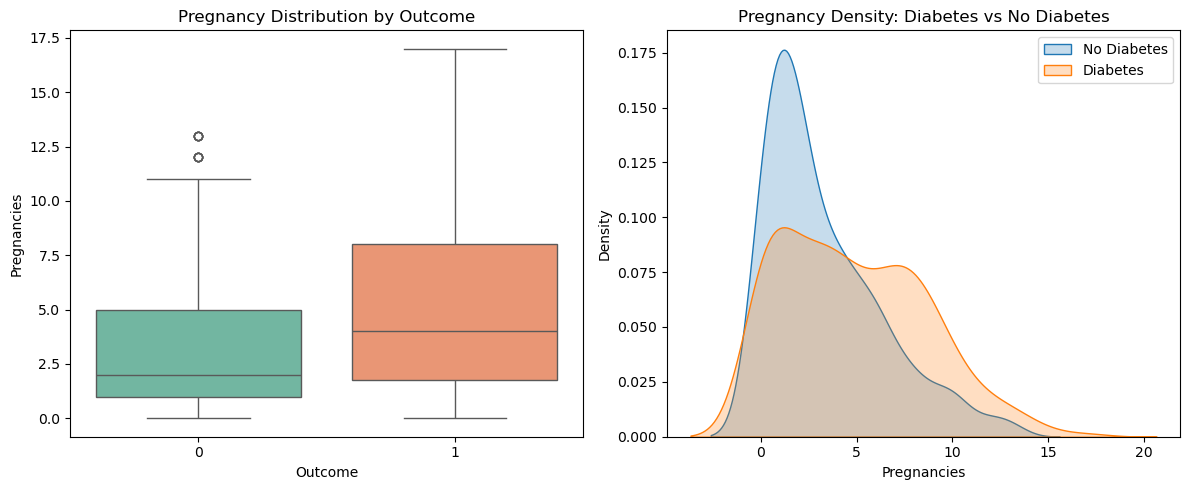

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Outcome', y='Pregnancies', data=df, palette='Set2')
plt.title('Pregnancy Distribution by Outcome')

plt.subplot(1, 2, 2)
sns.kdeplot(df[df['Outcome'] == 0]['Pregnancies'], label='No Diabetes', shade=True)
sns.kdeplot(df[df['Outcome'] == 1]['Pregnancies'], label='Diabetes', shade=True)
plt.title('Pregnancy Density: Diabetes vs No Diabetes')
plt.legend()

plt.tight_layout()
plt.show()

<Axes: xlabel='Outcome', ylabel='Pregnancies'>

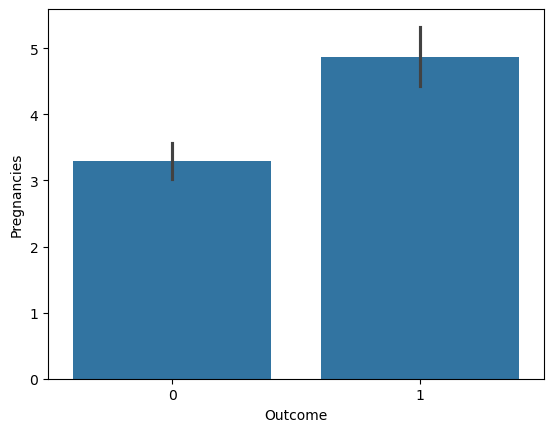

In [17]:
sns.barplot(x=df['Outcome'],y=df['Pregnancies'])

In [18]:
from scipy import stats

no_diabetes = df[df['Outcome'] == 0]['Pregnancies']
has_diabetes = df[df['Outcome'] == 1]['Pregnancies']

t_stat, p_val = stats.ttest_ind(no_diabetes, has_diabetes)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: Significant. We reject the Null Hypothesis (Pregnancies affect Outcome).")
else:
    print("Result: Not Significant. We fail to reject the Null Hypothesis.")

T-Statistic: -6.2984
P-Value: 0.0000
Result: Significant. We reject the Null Hypothesis (Pregnancies affect Outcome).


Analysis shows a highly significant relationship between pregnancies and diabetes ($p < 0.05$), meaning this is a key predictor for your model. The "No Diabetes" group peaks at 1-2 pregnancies, while the "Diabetes" group has a much higher and flatter distribution, often spanning 5-10 pregnancies. Statistically, the large T-statistic (-6.29) confirms that the gap between these two groups is not due to random chance. This suggests your Logistic Regression model will assign a positive weight to this feature, as higher pregnancy counts correlate with increased risk.

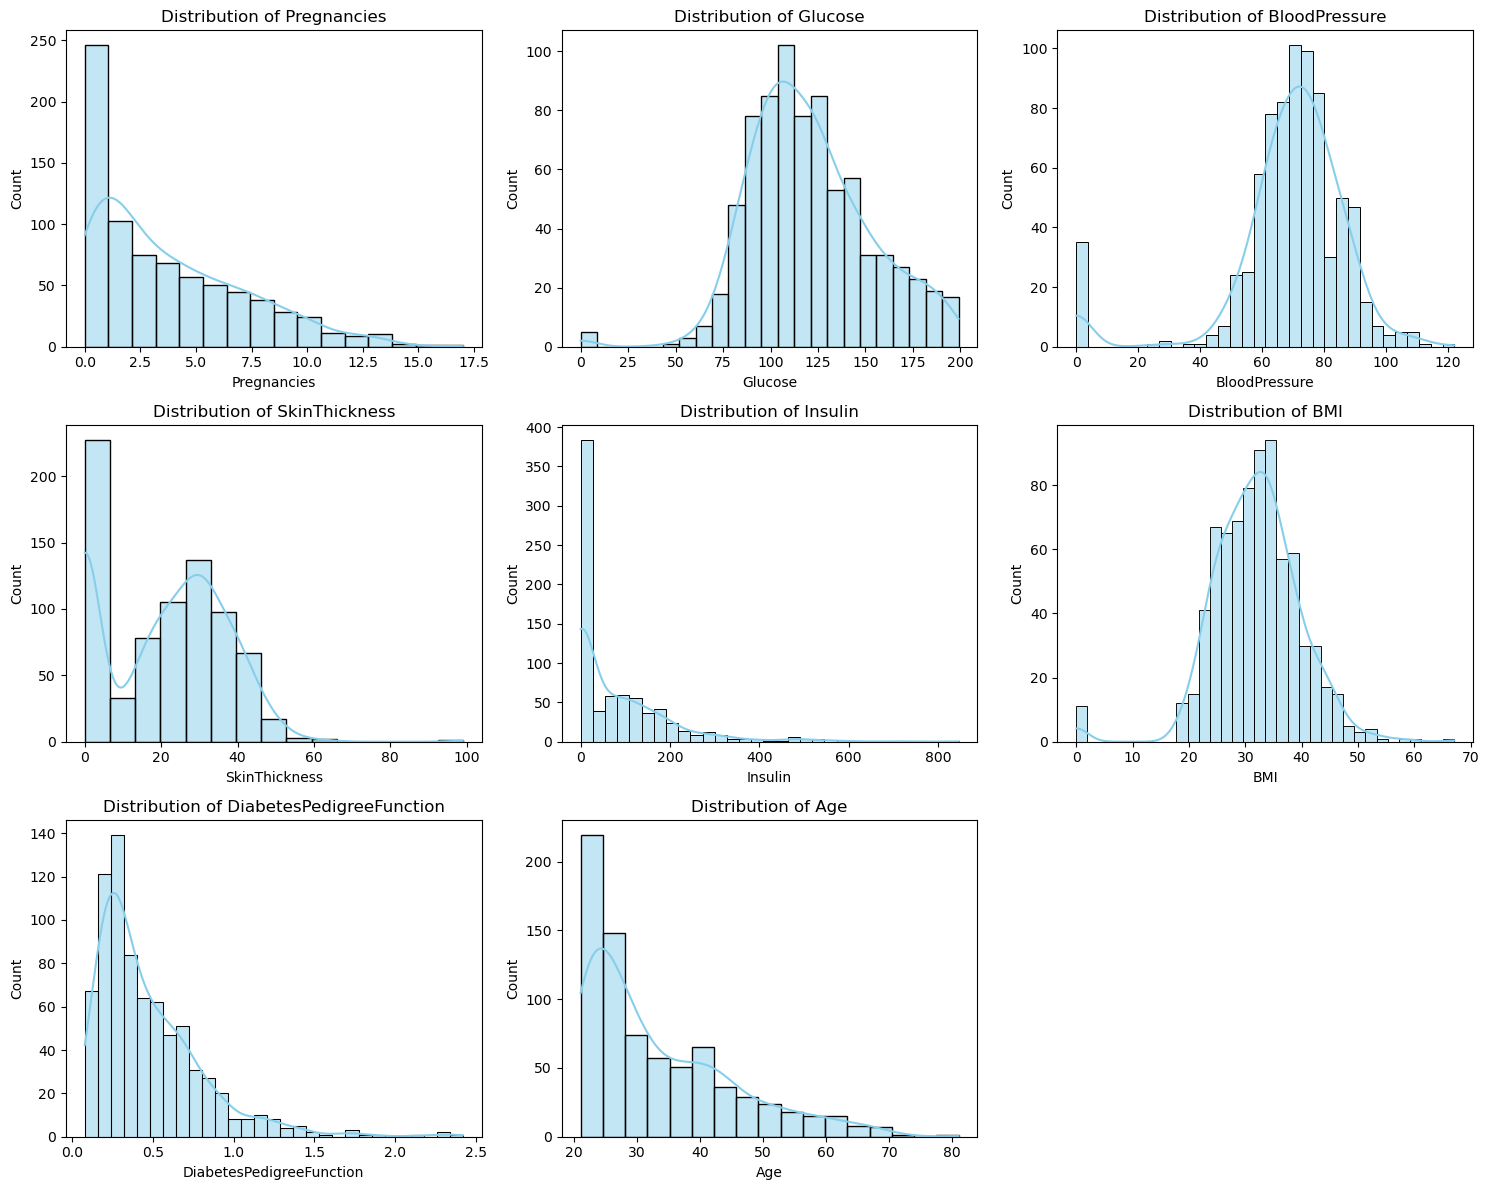

In [19]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(df.columns[:-1]): 
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

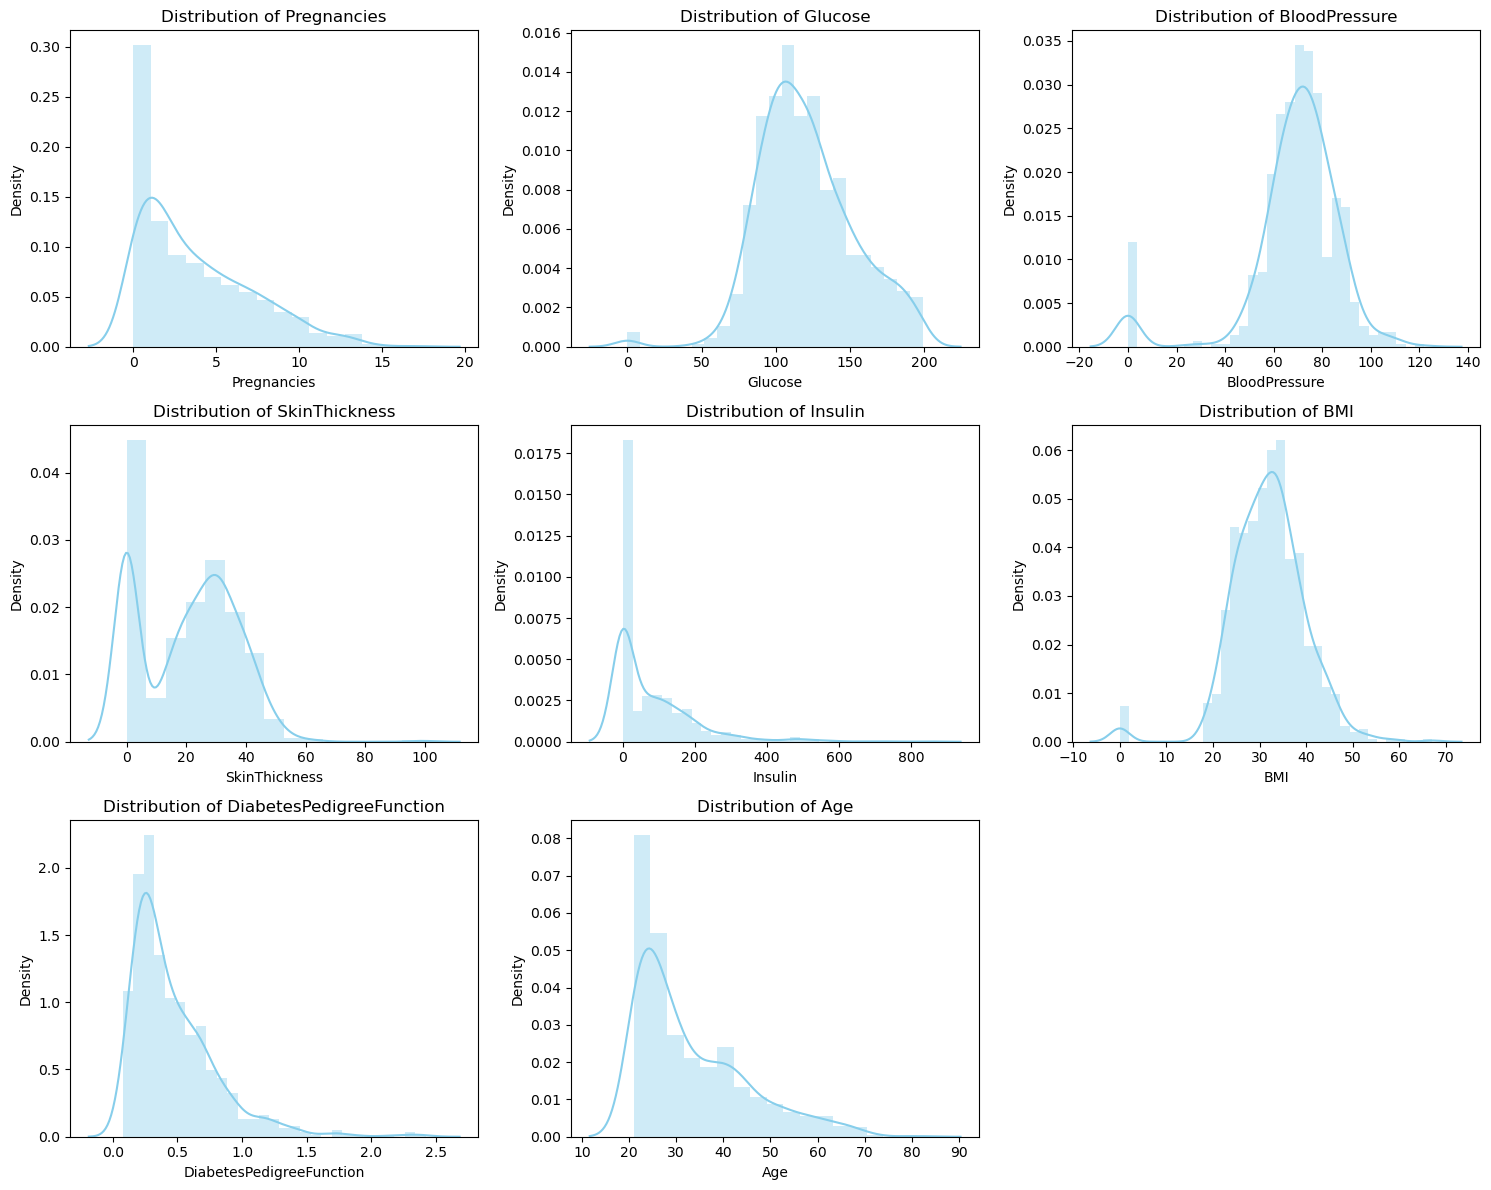

In [20]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(df.columns[:-1]): 
    plt.subplot(3, 3, i+1)
    sns.distplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

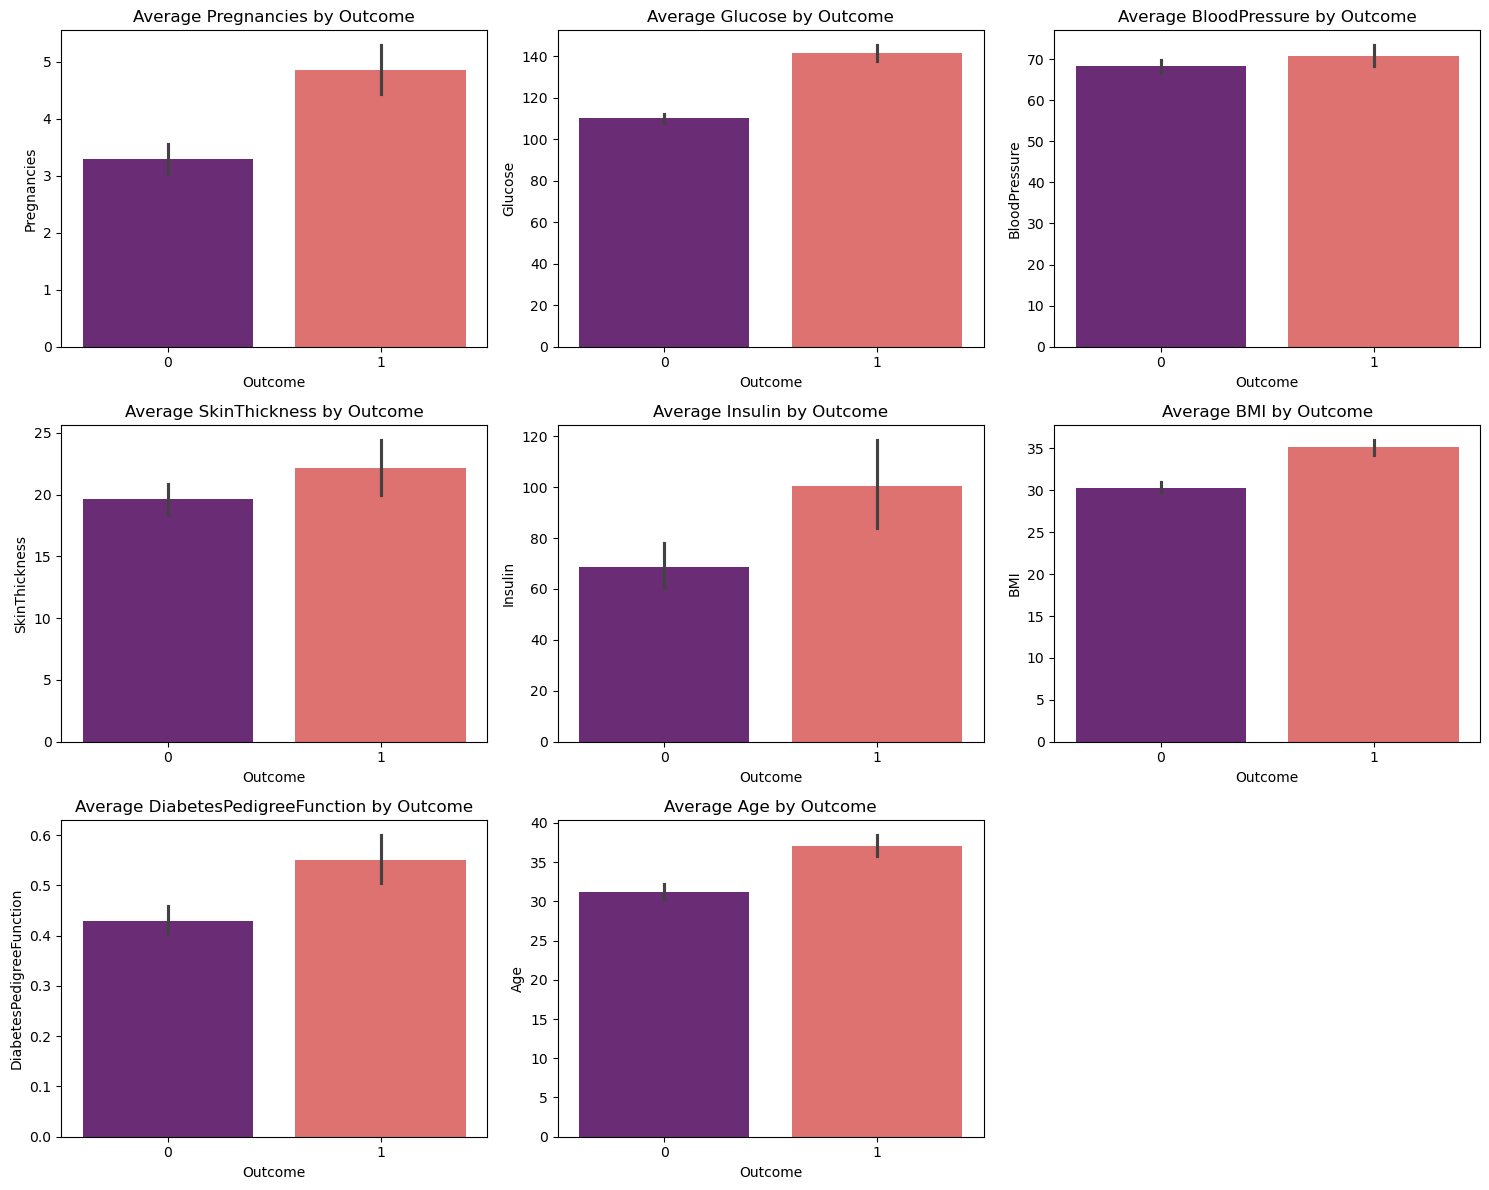

In [21]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(3, 3, i+1)
    sns.barplot(x='Outcome', y=col, data=df, palette='magma')
    plt.title(f'Average {col} by Outcome')
plt.tight_layout()
plt.show()

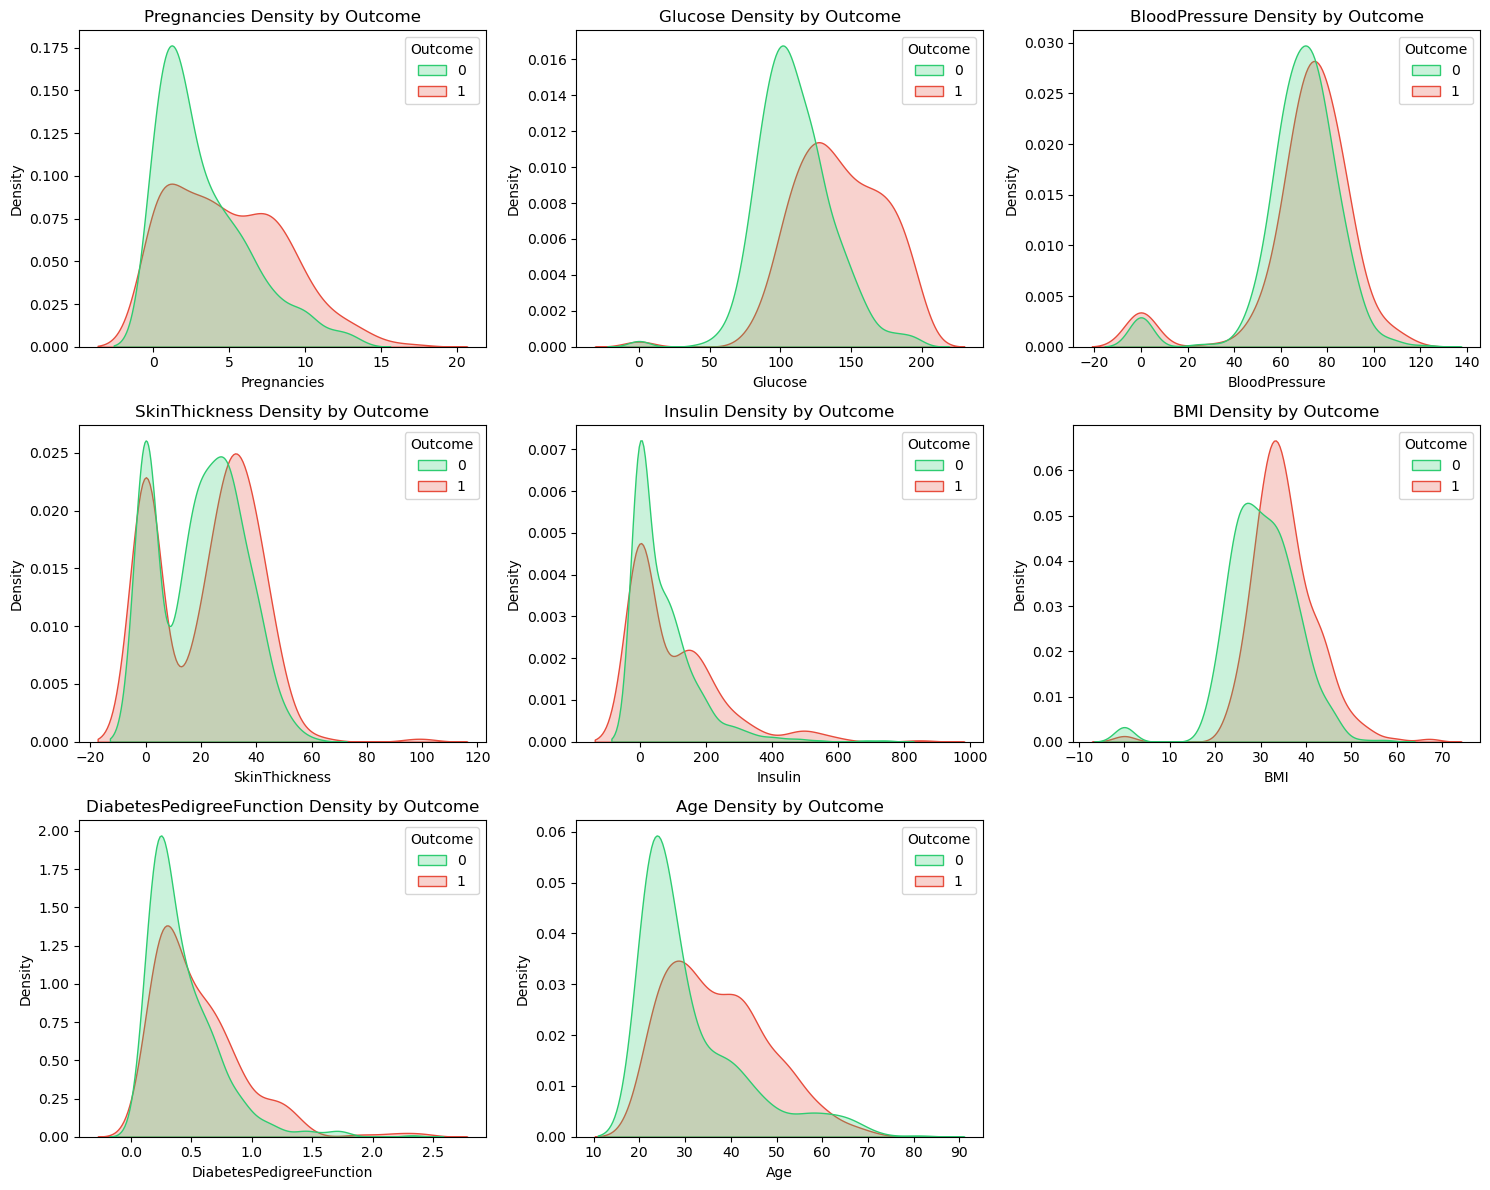

In [22]:
custom_colors = ["#2ecc71", "#e74c3c"] 

plt.figure(figsize=(15, 12))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(3, 3, i+1)
    sns.kdeplot(data=df, x=col, hue='Outcome', fill=True, common_norm=False, palette=custom_colors)
    plt.title(f'{col} Density by Outcome')
plt.tight_layout()
plt.show()

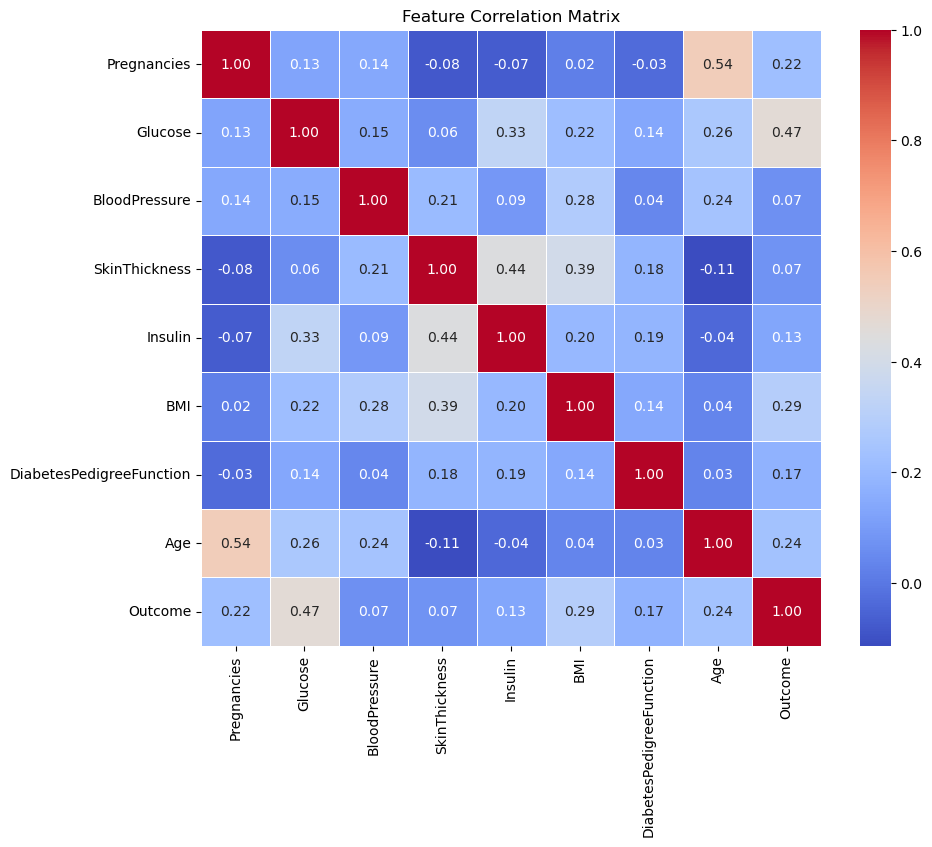

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

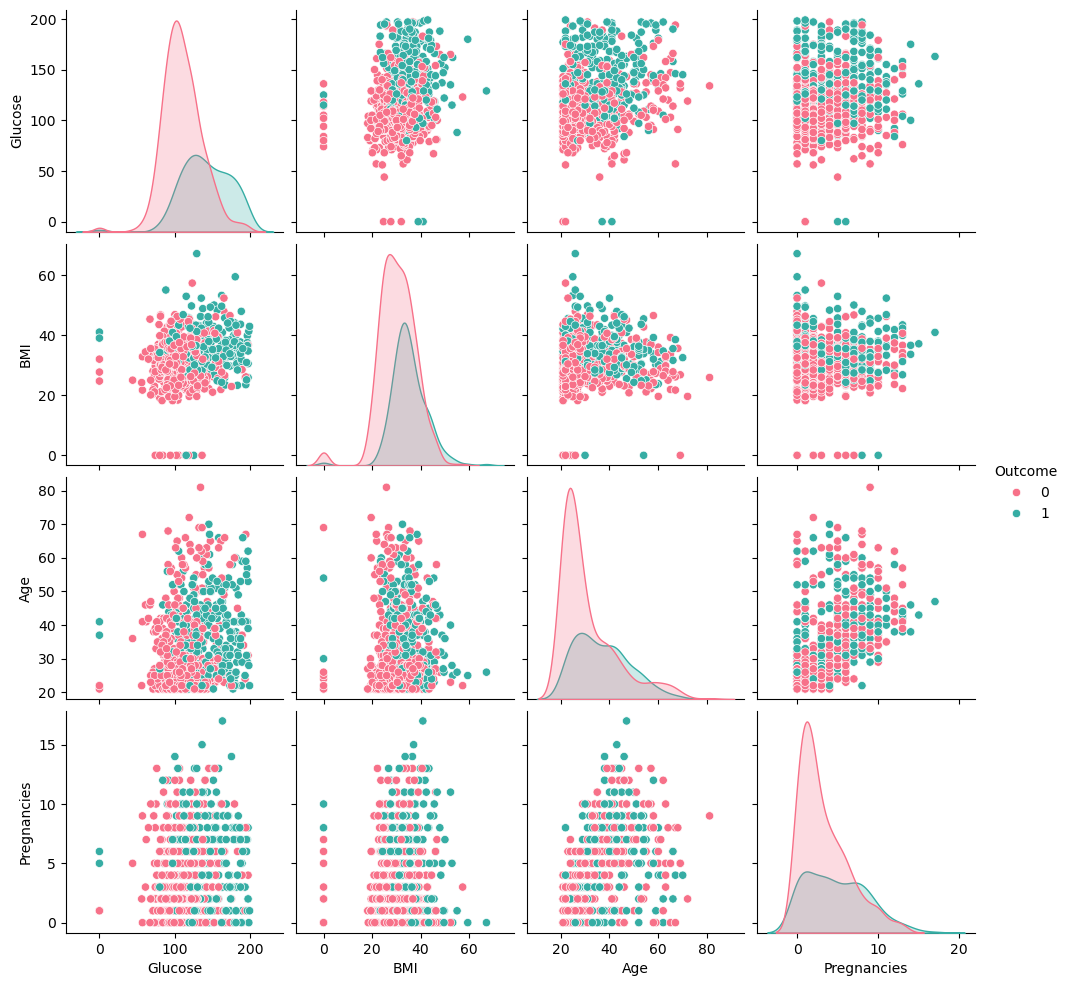

In [24]:
# To keep it fast, we pick the most important features
important_features = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'Outcome']
sns.pairplot(df[important_features], hue='Outcome', palette='husl', diag_kind='kde')
plt.show()

In [25]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [26]:
import pandas as pd
from scipy import stats

features = df.columns[:-1]
results = []

for col in features:
    group0 = df[df['Outcome'] == 0][col]
    group1 = df[df['Outcome'] == 1][col]
    
    t_stat, p_val = stats.ttest_ind(group0, group1)
    
    results.append({
        'Feature': col,
        'T-Statistic': round(t_stat, 4),
        'P-Value': round(p_val, 4),
        'Significant (p < 0.05)': 'Yes' if p_val < 0.05 else 'No'
    })

hypothesis_df = pd.DataFrame(results)
print(hypothesis_df)

                    Feature  T-Statistic  P-Value Significant (p < 0.05)
0               Pregnancies      -6.2984   0.0000                    Yes
1                   Glucose     -14.6001   0.0000                    Yes
2             BloodPressure      -1.8047   0.0715                     No
3             SkinThickness      -2.0747   0.0383                    Yes
4                   Insulin      -3.6443   0.0003                    Yes
5                       BMI      -8.4718   0.0000                    Yes
6  DiabetesPedigreeFunction      -4.8858   0.0000                    Yes
7                       Age      -6.7927   0.0000                    Yes


In [27]:
cols_to_fix = ['Insulin','SkinThickness']
for col in cols_to_fix:
    df[col] = df[col].replace(0, df[col].median())

## Data Preparation

In [28]:
X=df.drop(['Outcome','BloodPressure'],axis=1)
y=df['Outcome']


In [29]:
X.shape

(768, 7)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

## Model Building

In [32]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

In [33]:
lr.coef_

array([[ 0.19740318,  1.05229534,  0.06432799, -0.18572115,  0.69339234,
         0.22611549,  0.37141961]])

In [34]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(X_train, y_train)
print(f"Best Params: {grid.best_params_}")

Best Params: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}


In [35]:
model=grid.best_estimator_

## Model Evaluation

In [36]:
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy:  0.7532
Precision: 0.6667
Recall:    0.6182
F1 Score:  0.6415

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



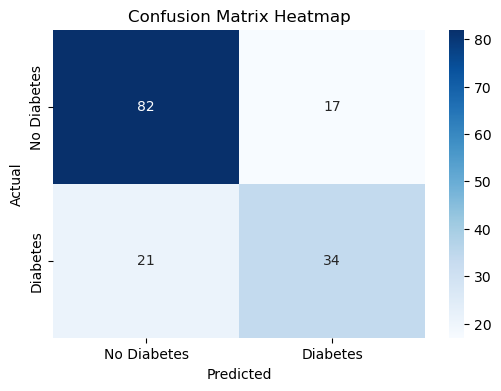

In [37]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes', 'Diabetes'], 
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

ROC-AUC Score: 0.8127


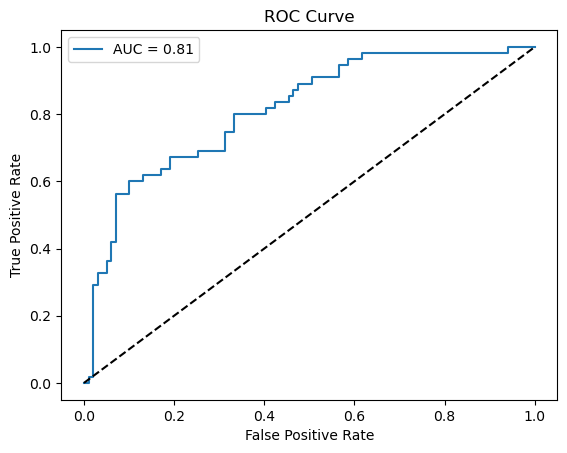

In [38]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--') # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
import joblib
joblib.dump(model, "model.pkl")

loaded_model = joblib.load("model.pkl")
predictions = loaded_model.predict(X_test)
print(predictions)

[0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 1 1 1 1 1 1 1
 0 0 0 0 1 1 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0
 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 1 1 0 0 1 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0]




---

### 1. What is the difference between precision and recall?

The primary difference lies in the **focus of evaluation**: Precision measures the reliability of positive predictions, while Recall measures the model's ability to find all actual positive instances.

* **Precision (Specificity of Positive Predictions):** Out of all the instances the model *predicted* as positive, how many were actually positive? It focuses on minimizing **False Positives**.
* *When to prioritize:* When the cost of a false alarm is high (e.g., Spam detection—you don't want a crucial work email sent to the spam folder).
* *Formula:* 
$$\text{Precision} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Positives (FP)}}$$




* **Recall / Sensitivity:** Out of all the *actual* positive instances in the dataset, how many did the model successfully identify? It focuses on minimizing **False Negatives**.
* *When to prioritize:* When missing a positive instance is dangerous or costly (e.g., Medical diagnosis—missing a patient with a disease is much worse than running a follow-up test on a healthy person).
* *Formula:* 
$$\text{Recall} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Negatives (FN)}}$$





> **The Trade-off:** They are often in inverse tension. Improving precision typically lowers recall and vice-versa. To balance them, data scientists often look at the **F1-Score**, which is the harmonic mean of both.

---

### 2. What is cross-validation, and why is it important in binary classification?

**Cross-Validation (CV)** is a resampling technique used to evaluate a machine learning model's performance by partitioning the dataset into multiple complementary subsets. The model is trained on some subsets and validated on the remaining subset, repeating this process iteratively so every data point gets a turn to be in both training and testing configurations.

The most common version is **k-Fold Cross-Validation**, where the data is split into $k$ equal parts (folds).

#### Why is it crucially important in Binary Classification?

1. **Prevents Overfitting:** A single train/test split can result in a "lucky" or "unlucky" distribution of data. Cross-validation ensures the evaluation metric (like Accuracy, ROC-AUC, or F1-score) is stable and generalizes well to unseen data.
2. **Mitigates Class Imbalance Risks (via Stratified CV):** In binary classification, datasets are frequently skewed (e.g., 95% non-fraud, 5% fraud). Standard cross-validation might accidentally create folds with zero minority class samples. **Stratified k-fold cross-validation** forces every fold to maintain the exact same percentage of 0s and 1s as the original dataset, ensuring fair evaluation.
3. **Optimizes Hyperparameters Safely:** When tuning threshold cutoffs or model parameters (like the regularization strength $C$ in Logistic Regression), cross-validation acts as a safeguard. It ensures parameters are selected because they perform robustly across the entire dataset, rather than overfitting to a single static validation split.